In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

In [2]:
file_path = "Indian_Climate_Dataset_2024_2025.csv"

df = pd.read_csv(file_path)

# Standardize column names (VERY IMPORTANT)
df.columns = df.columns.str.strip().str.replace(" ", "_")

df.head()

,Date,City,State,Temperature_Max_(°C),Temperature_Min_(°C),Temperature_Avg_(°C),Humidity_(%),Rainfall_(mm),Wind_Speed_(km/h),AQI,AQI_Category,Pressure_(hPa),Cloud_Cover_(%)
0,2024-01-01,Mumbai,Maharashtra,32.5,18.0,25.2,77.6,0.0,3.3,259,Poor,1020.3,62.1
1,2024-01-01,Delhi,Delhi,25.4,10.7,18.1,84.1,0.0,9.0,130,Moderate,1008.4,46.0
2,2024-01-01,Bengaluru,Karnataka,37.2,30.8,34.0,49.0,3.7,6.6,54,Satisfactory,1008.0,61.3
3,2024-01-01,Chennai,Tamil Nadu,37.2,30.4,33.8,34.2,9.5,9.0,176,Moderate,993.4,70.0
4,2024-01-01,Kolkata,West Bengal,27.4,17.5,22.5,32.2,9.1,9.2,97,Satisfactory,1008.2,56.9


In [3]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (7310, 13)
<class 'pandas.DataFrame'>
RangeIndex: 7310 entries, 0 to 7309
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  7310 non-null   str    
 1   City                  7310 non-null   str    
 2   State                 7310 non-null   str    
 3   Temperature_Max_(°C)  7310 non-null   float64
 4   Temperature_Min_(°C)  7310 non-null   float64
 5   Temperature_Avg_(°C)  7310 non-null   float64
 6   Humidity_(%)          7310 non-null   float64
 7   Rainfall_(mm)         7310 non-null   float64
 8   Wind_Speed_(km/h)     7310 non-null   float64
 9   AQI                   7310 non-null   int64  
 10  AQI_Category          7310 non-null   str    
 11  Pressure_(hPa)        7310 non-null   float64
 12  Cloud_Cover_(%)       7310 non-null   float64
dtypes: float64(8), int64(1), str(4)
memory usage: 742.6 KB


,Temperature_Max_(°C),Temperature_Min_(°C),Temperature_Avg_(°C),Humidity_(%),Rainfall_(mm),Wind_Speed_(km/h),AQI,Pressure_(hPa),Cloud_Cover_(%)
count,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000
mean,34.952161,25.006402,29.980192,62.653516,8.231300,13.522763,193.759508,1007.358577,52.630055
std,5.781372,6.476264,5.966698,18.680171,17.758208,6.562729,89.182569,10.109978,27.327729
min,25.000000,10.100000,17.600000,30.000000,0.000000,2.000000,40.000000,990.000000,5.000000
25%,30.000000,19.900000,25.000000,46.400000,0.000000,7.900000,116.000000,998.700000,28.925000
50%,34.900000,25.000000,30.000000,62.700000,0.000000,13.500000,194.000000,1007.300000,52.700000
75%,40.000000,30.000000,35.000000,78.700000,6.300000,19.100000,270.000000,1016.200000,76.200000
max,45.000000,39.800000,42.300000,95.000000,79.900000,25.000000,349.000000,1025.000000,100.000000


In [14]:
# Check missing values
print(df.isnull().sum())

# Numeric columns → fill with median
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns → FIXED (no warnings)
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

Date                    0
City                    0
State                   0
Temperature_Max_(°C)    0
Temperature_Min_(°C)    0
Temperature_Avg_(°C)    0
Humidity_(%)            0
Rainfall_(mm)           0
Wind_Speed_(km/h)       0
AQI                     0
AQI_Category            0
Pressure_(hPa)          0
Cloud_Cover_(%)         0
Month                   0
Year                    0
Season                  0
dtype: int64


In [15]:
# Try common date column names
for col in df.columns:
    if "date" in col.lower():
        df[col] = pd.to_datetime(df[col], errors='coerce')
        date_col = col
        break

# Create time features
df['Month'] = df[date_col].dt.month
df['Year'] = df[date_col].dt.year

In [16]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8,9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df['Season'] = df['Month'].apply(get_season)

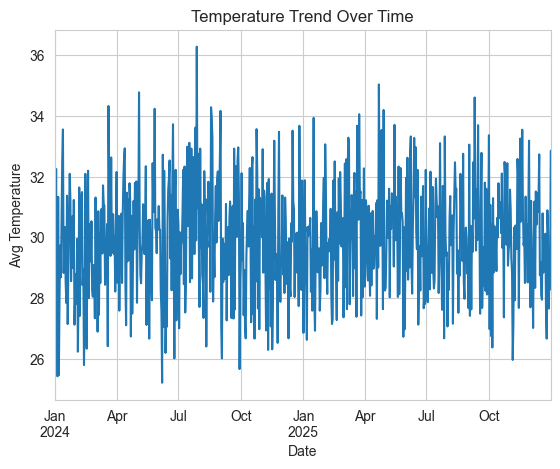

In [17]:
temp_col = [col for col in df.columns if "temp" in col.lower() and "avg" in col.lower()]

if temp_col:
    df.groupby(date_col)[temp_col[0]].mean().plot()
    plt.title("Temperature Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Avg Temperature")
    plt.show()

=v

In [ ]:
the Temperature shows a clear seasonal pattern across the dataset's Time period rising during summer months ans dipping in winters. this aligns with expected seasonal variation in climate

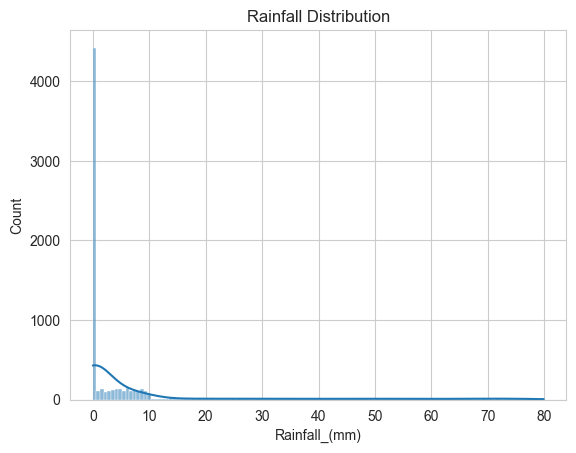

In [18]:
rain_col = [col for col in df.columns if "rain" in col.lower()]

if rain_col:
    sns.histplot(df[rain_col[0]], kde=True)
    plt.title("Rainfall Distribution")
    plt.show()

In [ ]:
rainfall is heavily right skewed most days show low or zero rainfall, witha smaller number of days showing high rainfall (monsoon spikes) this is typical since most days in a year falls outside monsoon times.

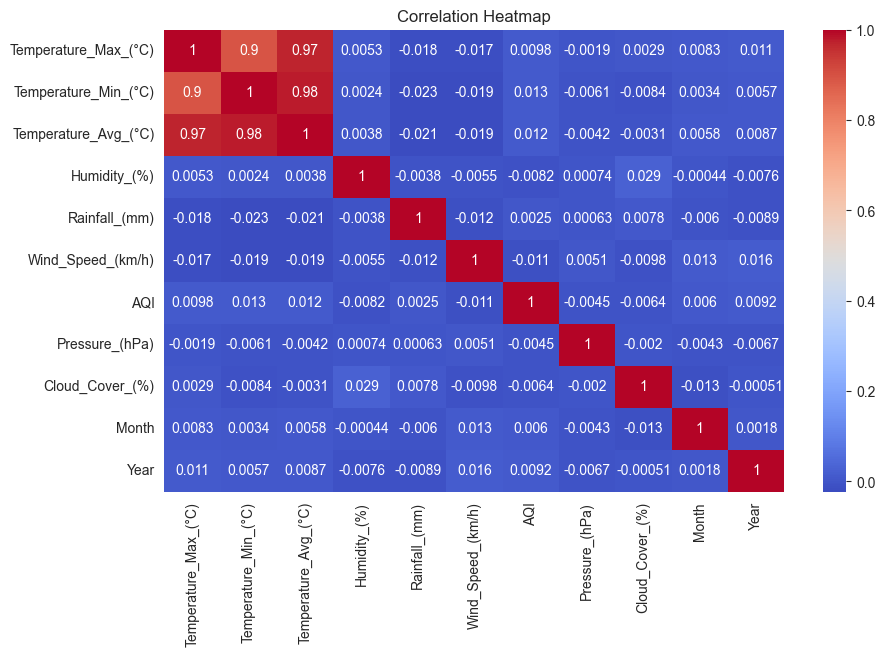

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
Temprature max, min, and avg very strongly corelated with each other.however AOI humidity, rainfall almost no related to each other. this suggest variables largely independent in this dataset.

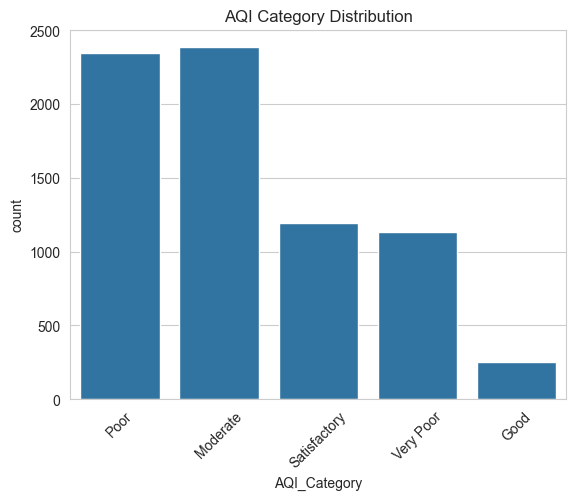

In [20]:
aqi_cat = [col for col in df.columns if "aqi" in col.lower() and "cat" in col.lower()]

if aqi_cat:
    sns.countplot(x=df[aqi_cat[0]])
    plt.xticks(rotation=45)
    plt.title("AQI Category Distribution")
    plt.show()

In [ ]:
most readings indicating air quality is not in a good range.but also not consistently in a severe range.

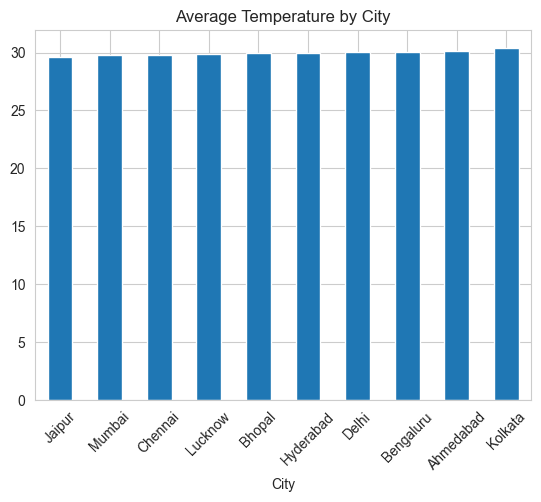

In [21]:
city_col = [col for col in df.columns if "city" in col.lower()]

if city_col and temp_col:
    df.groupby(city_col[0])[temp_col[0]].mean().sort_values().plot(kind='bar')
    plt.title("Average Temperature by City")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
all 10 cities show fairly similar Temprature range. ranging between 29.5-30. kolkata have the higest average followed by ahmedabad. while jaipur has the lowest.

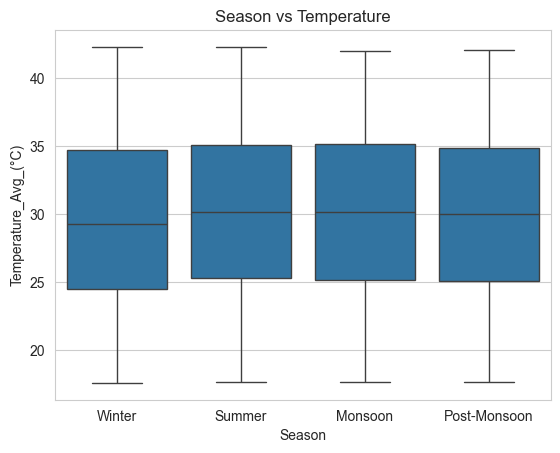

In [22]:
if temp_col:
    sns.boxplot(x='Season', y=temp_col[0], data=df)
    plt.title("Season vs Temperature")
    plt.show()

In [ ]:
summer has the highest median temprature and widest spread. while winter has the lowest.monsoon and post monsoon falls in between.

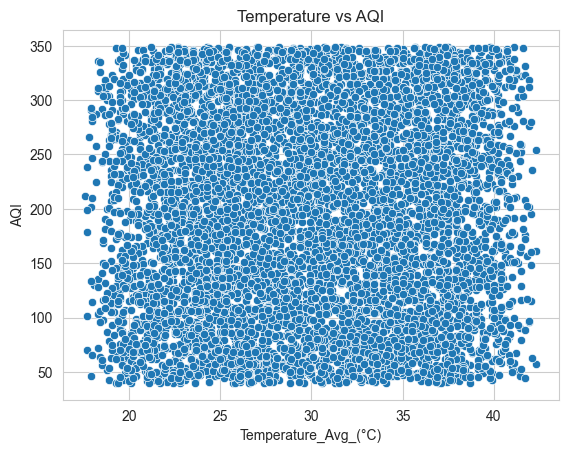

In [23]:
aqi_col = [col for col in df.columns if col.lower() == "aqi"]

if aqi_col and temp_col:
    sns.scatterplot(x=df[temp_col[0]], y=df[aqi_col[0]])
    plt.title("Temperature vs AQI")
    plt.show()

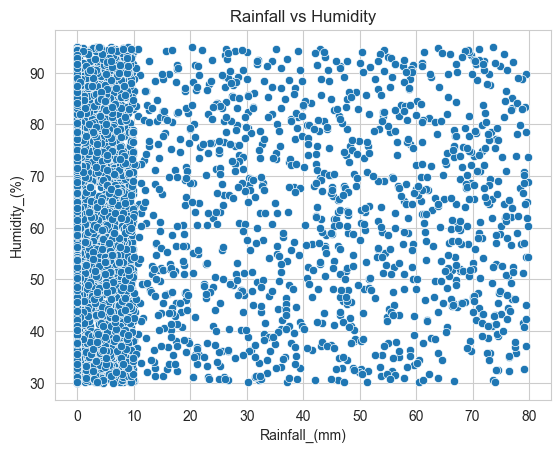

In [24]:
hum_col = [col for col in df.columns if "humid" in col.lower()]

if rain_col and hum_col:
    sns.scatterplot(x=df[rain_col[0]], y=df[hum_col[0]])
    plt.title("Rainfall vs Humidity")
    plt.show()


In [ ]:
humidity tends to increase alongside rainfall, showing a positive relationship.since more rainfall means higher moisture in the air